<a href="https://colab.research.google.com/github/MuhammadMahmoudAli/Quantium_Customer_Behavior_Analysis/blob/main/Ames_Housing_Pricing_Estimator_Project_IPYNB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1: Load the Data & Perform Initial Inspection

### *Importing the important libraries*

In [23]:
import sys
print(sys.executable)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import csv
# Optional But good for clean output
sns.set_style('whitegrid')
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

/usr/bin/python3


### *load the dataset*

### *Intial data inspection*

In [24]:
df_train = pd.read_csv(r"/content/AmesHousing.csv")
# Display first 5 rows
print(df_train.head())

#Get a concise summary of the DataFrame
print('\nDataFrame Info:')
df_train.info()

# Generate descriptive statistics of the numerical features
print("\nDescriptive Statistics of Numerical Features:")

display(df_train.describe())

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0       

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### DataSet Summary
* The dataset has 2932 rows and 82 columns.

* There are a mix of numerical and categorical features.

* Some columns have missing values (as indicated by the info() output).

* The target variable, SalePrice, appears to be right-skewed based on the describe() output (high standard deviation and a max value that is very far   from the mean).

### *Data Preprocessing & Cleaning*

#### A1. Quantify Missing Values

In [26]:
total_missing = df_train.isnull().sum().sort_values(ascending=False)
percent_missing = (df_train.isnull().sum() / df_train.isnull().count().sort_values(ascending=False))
percent_missing_formatted = percent_missing.map('{:.2%}'.format)
missing_data = pd.concat([total_missing, percent_missing_formatted], axis=1, keys=['Total', 'Percent'])
display(missing_data.head(20)) #Display the top 20 row

,Total,Percent
Pool QC,2917,99.56%
Misc Feature,2824,96.38%
Alley,2732,93.24%
Fence,2358,80.48%
Mas Vnr Type,1775,60.58%
Fireplace Qu,1422,48.53%
Lot Frontage,490,16.72%
Garage Qual,159,5.43%
Garage Yr Blt,159,5.43%
Garage Cond,159,5.43%


#### A2. Strategically Handle Missing Data
##### Action: (*I will drop columns with a very high percentage of missing values and impute the rest based on their data type.*)

In [27]:
# Drop columns with > 50% of missing Values
columns_to_drop = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Mas Vnr Type']
df_train = df_train.drop(columns=columns_to_drop)

# Impute catogorical features by filling with 'None'
for col in ['Fireplace Qu']:
    df_train[col] = df_train[col].fillna('None')

# Impute nemurical features with the meadian
df_train['Lot Frontage'] = df_train['Lot Frontage'].fillna(df_train['Lot Frontage'].median())

# Filling other remaining NaN values
for col in df_train.columns:
    if df_train[col].isnull().any():
        if df_train[col].dtype == 'object':
            df_train[col] = df_train[col].fillna(df_train[col].mode()[0])
        else:
            df_train[col] = df_train[col].fillna(df_train[col].median())

In [28]:
#Validating the cleaning proccess
total_missing = df_train.isnull().sum().sort_values(ascending=False)
percent_missing = (df_train.isnull().sum() / df_train.isnull().count().sort_values(ascending=False))
percent_missing_formatted = percent_missing.map('{:.2%}'.format)
missing_data = pd.concat([total_missing, percent_missing_formatted], axis=1, keys=['Total', 'Percent'])
display(missing_data.head(20)) #Display the top 20 row

,Total,Percent
Order,0,0.00%
PID,0,0.00%
MS SubClass,0,0.00%
MS Zoning,0,0.00%
Lot Frontage,0,0.00%
Lot Area,0,0.00%
Street,0,0.00%
Lot Shape,0,0.00%
Land Contour,0,0.00%
Utilities,0,0.00%


### *Exploratory Data Analysis (EDA)*

* *Task 1: Understand the Target Variable (SalePrice)*
* *Task 2: Analyze Relationships with Numerical Features*
* *Task 3: Analyze Relationships with Categorical Features*

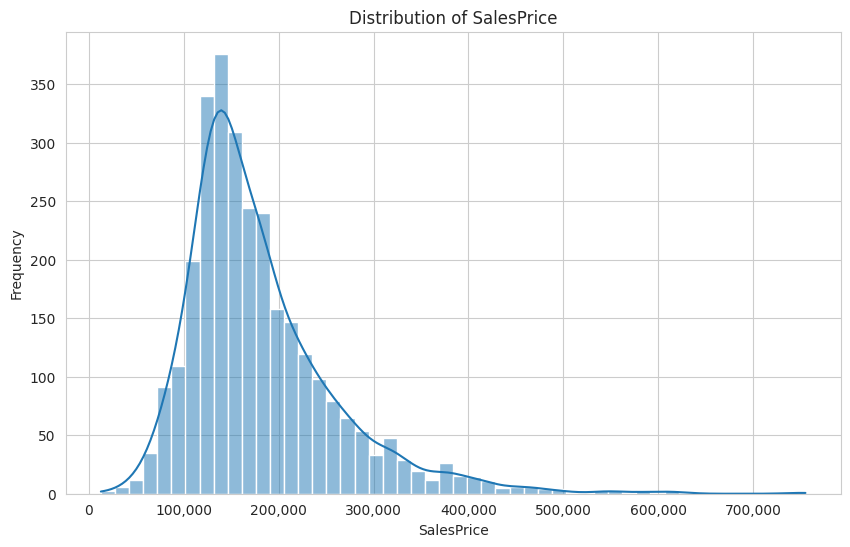

Statistical Summary of SalePrice:
count      2,930.00
mean     180,796.06
std       79,886.69
min       12,789.00
25%      129,500.00
50%      160,000.00
75%      213,500.00
max      755,000.00
Name: SalePrice, dtype: object

Skewness of SalePrice:1.74

KKurtosis of SalePrice:5.12


In [29]:
# Task_1: Understand The Target Variable

# Plot the distribution of SalePrice
plt.figure(figsize=(10, 6))
sns.histplot(df_train['SalePrice'], kde=True, bins=50)

# Format Y-axis eith commas as thousand separators
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'{int(x):,}'))

plt.title('Distribution of SalesPrice')
plt.xlabel('SalesPrice')
plt.ylabel('Frequency')
plt.show()


# Get Statistical summary
print("Statistical Summary of SalePrice:")
Summary = df_train['SalePrice'].describe().apply(lambda x: f"{x:,.2f}")
print(Summary)

# Calculate Skewness and Kurtosis
print(f"\nSkewness of SalePrice:{df_train['SalePrice'].skew():.2f}")
print(f"\nKKurtosis of SalePrice:{df_train['SalePrice'].kurt():.2f}")

### **1. Analysis of SalePrice Distribution**
The histogram of SalePrice shows a right-skewed distribution. This means the majority of houses are priced at the lower end of the scale, and there's a long tail extending to the right, representing a few very expensive homes. This is a common characteristic of real-world price data.

**Key Observation:**



*   The skewness suggests that a simple linear regression model might not be the best fit, as these models assume a more normal distribution of residuals.
*   To address this, we'll likely need to perform a logarithmic transformation on the SalePrice variable before modeling. This will pull in the long tail and make the distribution more symmetrical (closer to normal), improving the model's performance.






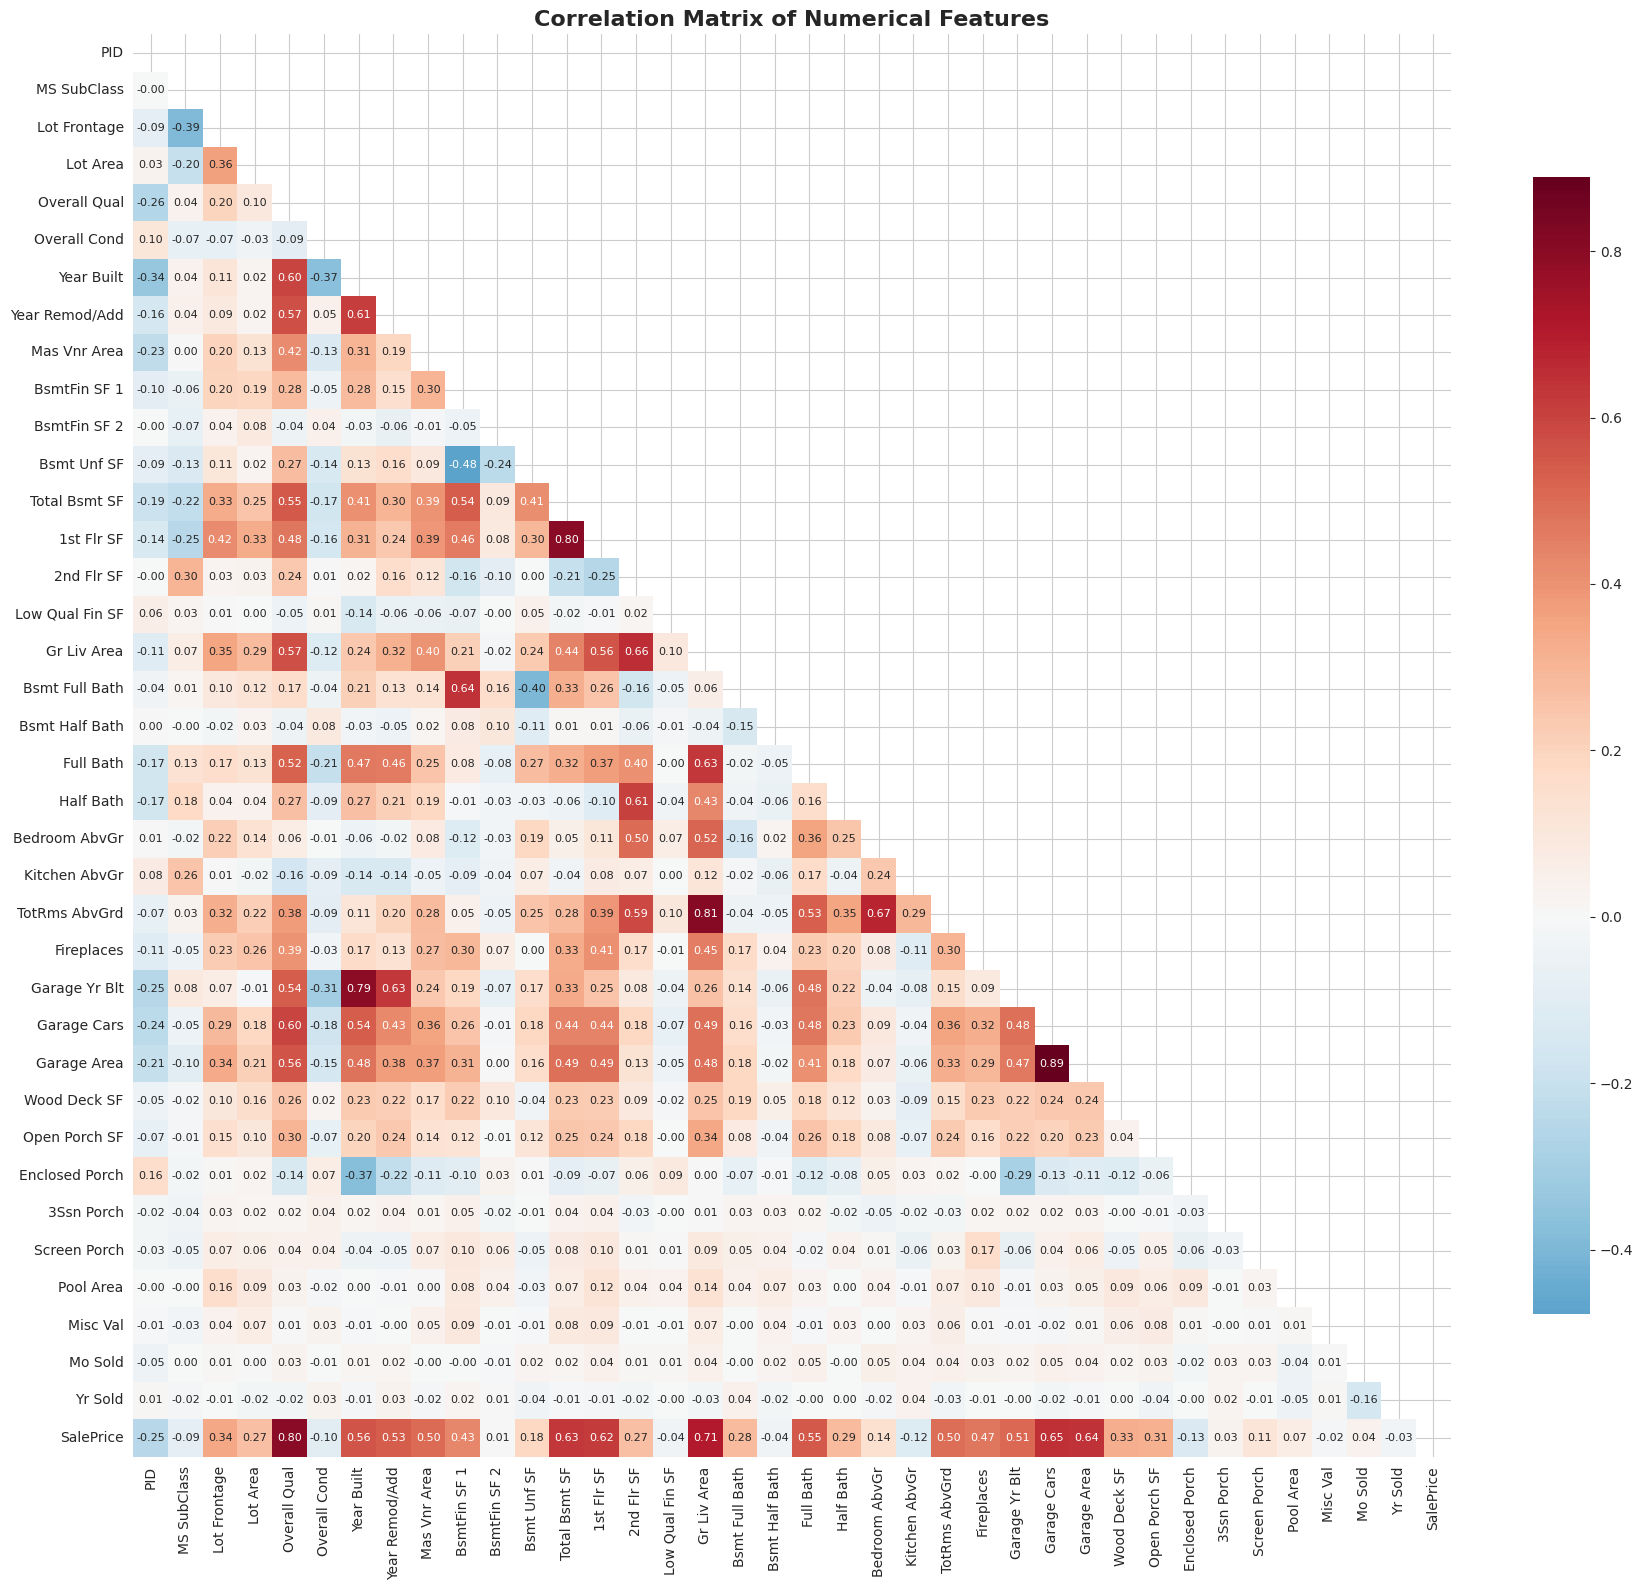

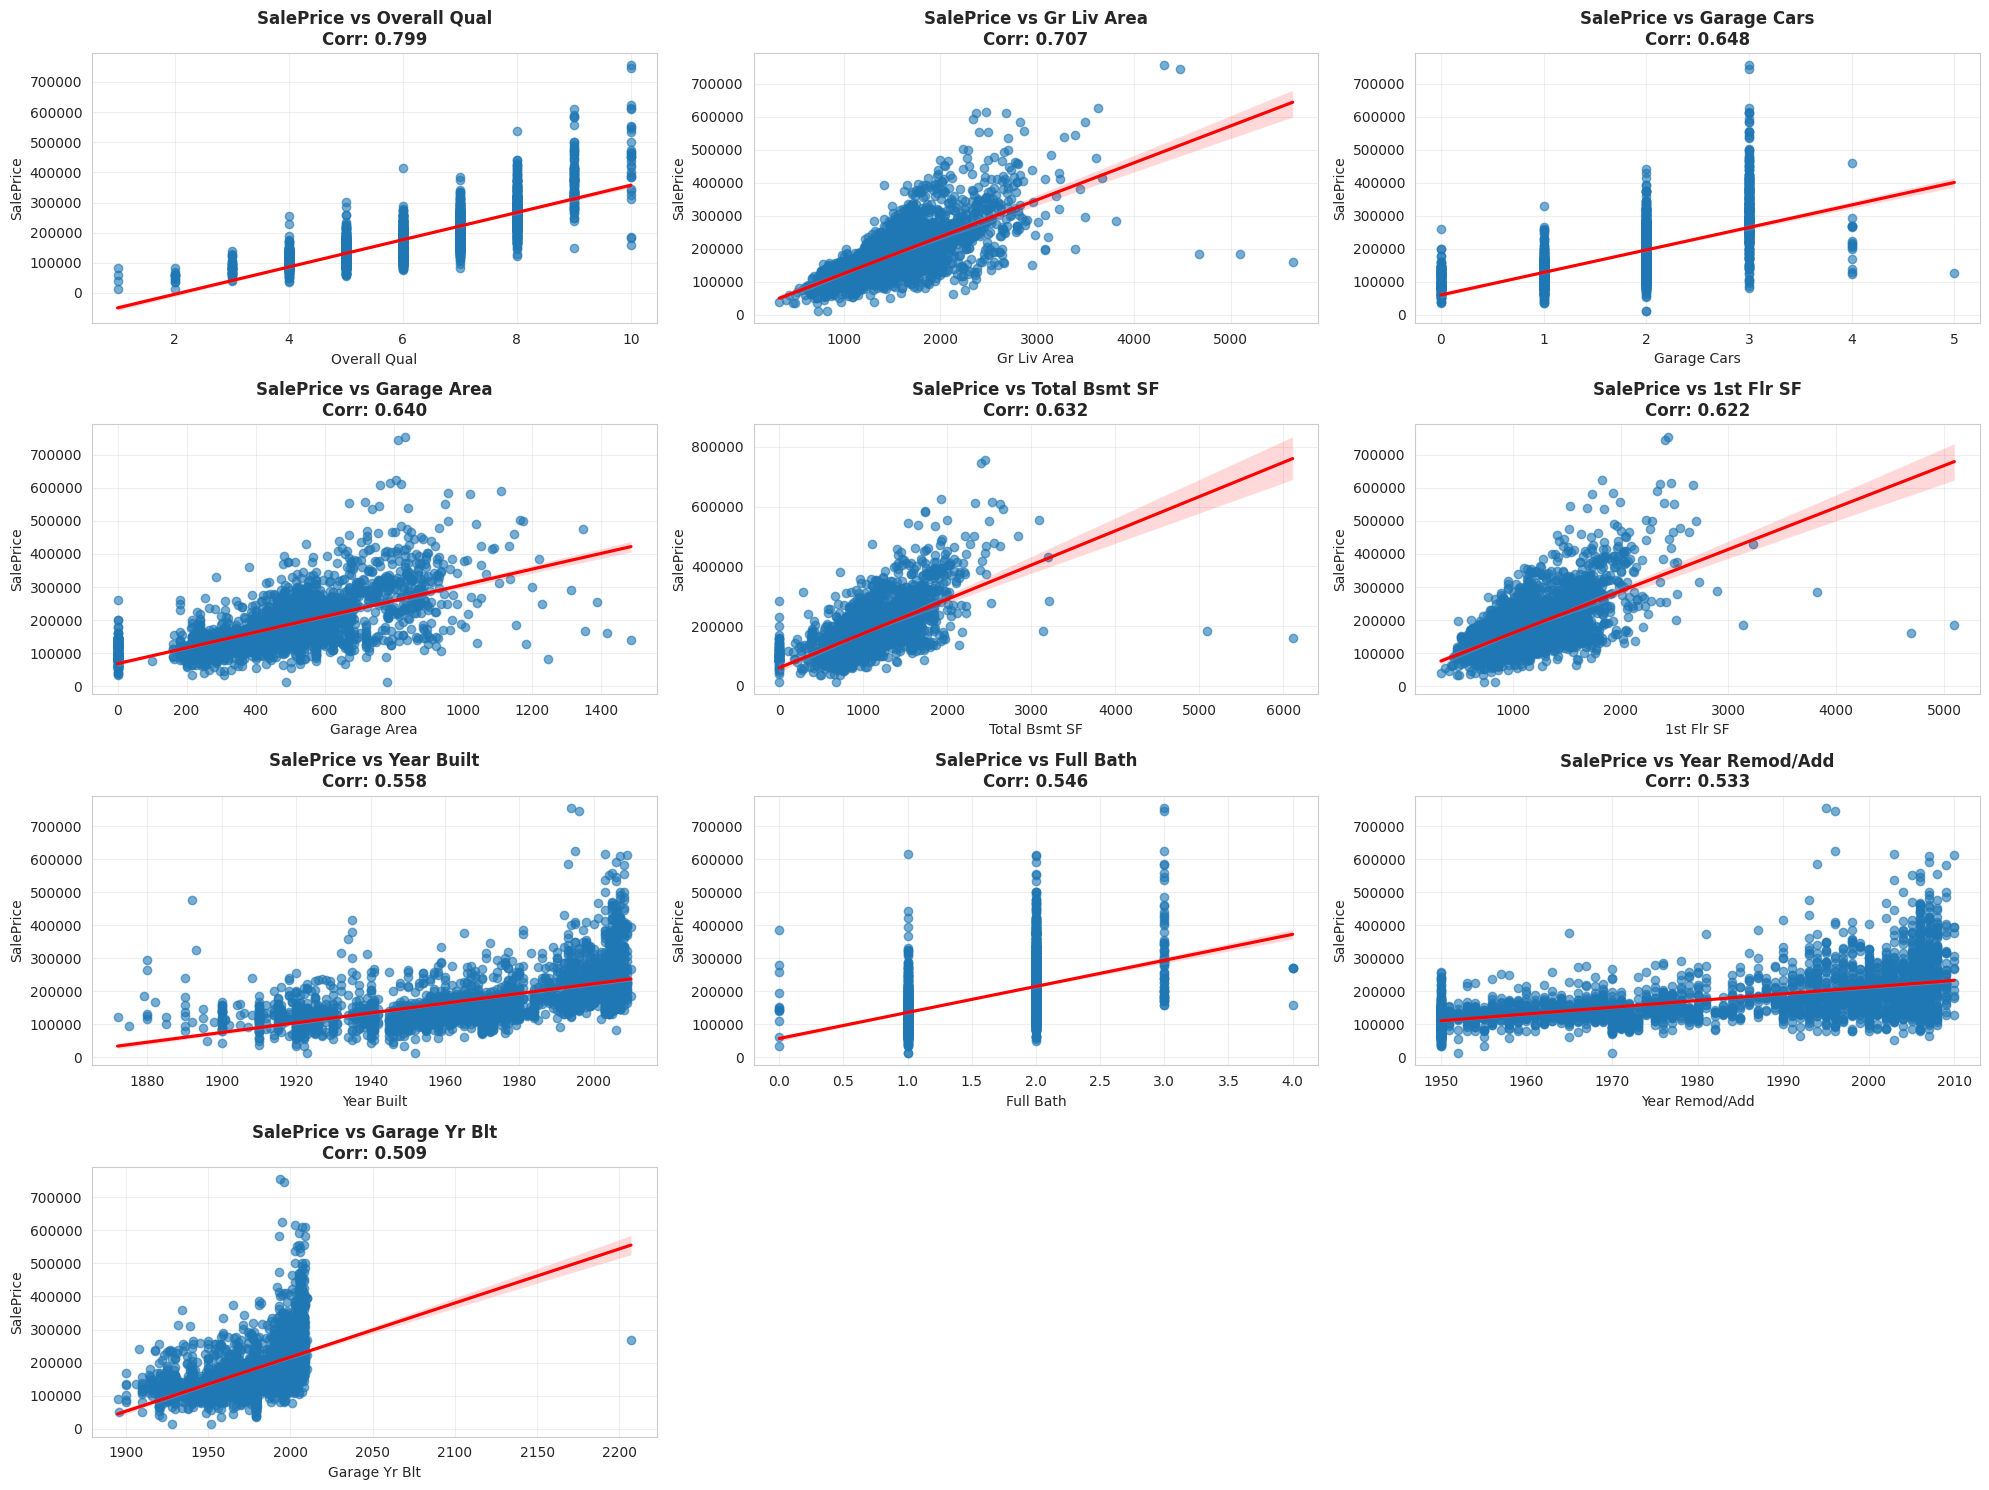

In [30]:
# Task_2: Analyze Relationships with Numerical Features
# Select only numerical features for the correlation matrix
numerical_features = df_train.select_dtypes(include=np.number).columns.tolist()

# The 'Order' column is an identifier, not a feature only ID
numerical_features.remove('Order')

# Create a correlation matrix
corr_matrix = df_train[numerical_features].corr()

# Enhanced heatmap with same size
plt.figure(figsize=(18, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Hide upper triangle
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            cbar_kws={"shrink": 0.8},
            annot_kws={'size': 8})
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Get the top 10 most correlated features with SalePrice
top_corr_features = corr_matrix['SalePrice'].abs().sort_values(ascending=False).index[1:11]

# Enhanced scatter plots for the top correlated features
plt.figure(figsize=(20, 15))
for i, feature in enumerate(top_corr_features):
    plt.subplot(4, 3, i+1)
    sns.regplot(x=feature, y='SalePrice', data=df_train,
                scatter_kws={'alpha': 0.6},
                line_kws={'color': 'red'})
    corr_val = corr_matrix.loc[feature, 'SalePrice']
    plt.title(f'SalePrice vs {feature}\nCorr: {corr_val:,.3f}', fontweight='bold')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **2. Analysis of Numerical Feature Relationships**
The correlation matrix and scatter plots reveal strong relationships between SalePrice and several key numerical features.

**Key Observations from Scatter Plots:**

*  OverallQual has a very high positive correlation (0.799) with SalePrice. The scatter plot shows a clear upward trend, indicating that higher quality ratings are strongly associated with higher prices.

*  Gr Liv Area (Above-ground living area) also shows a strong positive correlation (0.707). This is intuitive—larger homes tend to be more expensive. The scatter plot shows a clear linear relationship, but you can also spot a few outliers (the two data points in the top right, with very large Gr Liv Area but relatively low prices). These might be worth investigating.

*  Garage Cars and Garage Area are also highly correlated with SalePrice, which makes sense as a larger garage adds value. The plots show a clear progression as the number of cars or garage area increases.

*  Year Built and Year Remod/Add have a positive correlation, suggesting newer or more recently renovated homes fetch a higher price.

### **Conclusion**:
*We have successfully identified the most influential numerical features. We will use these in our model, and the strong correlations suggest that a linear regression model, even as a baseline, should perform reasonably well. The presence of outliers in some plots, like Gr Liv Area, is something we'll need to consider handling in the next phase.*

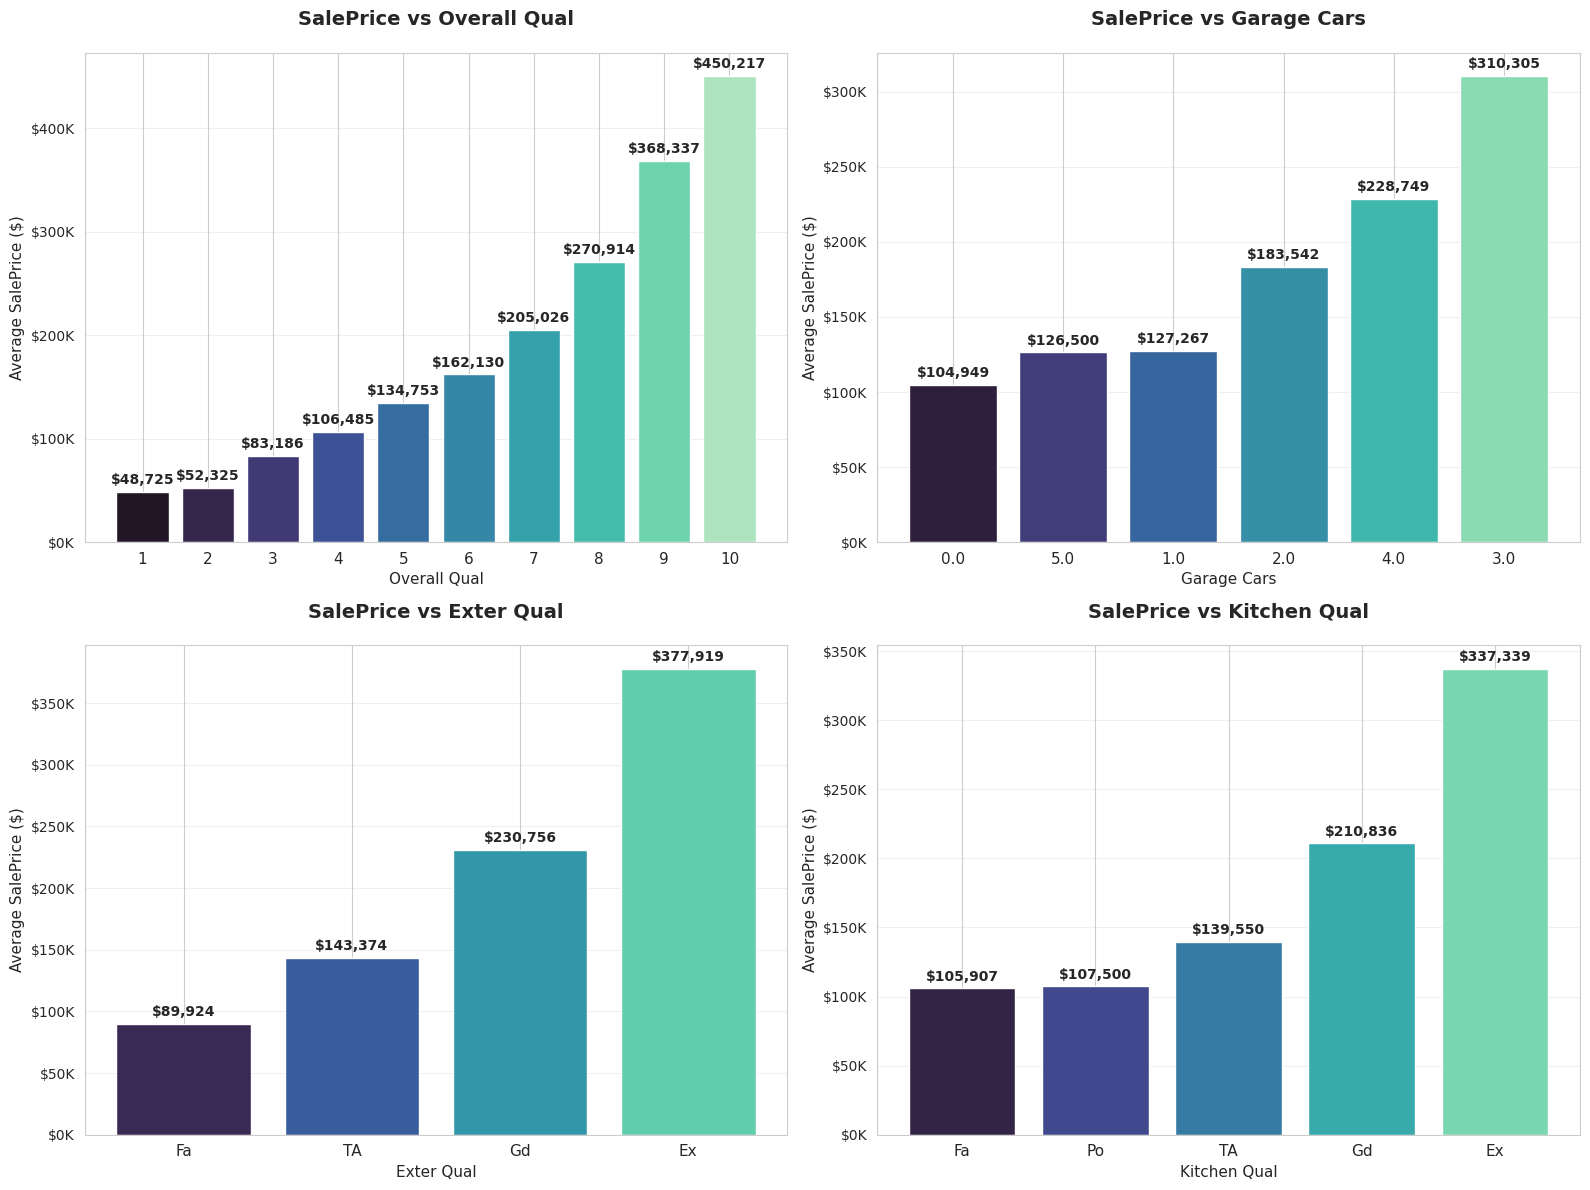

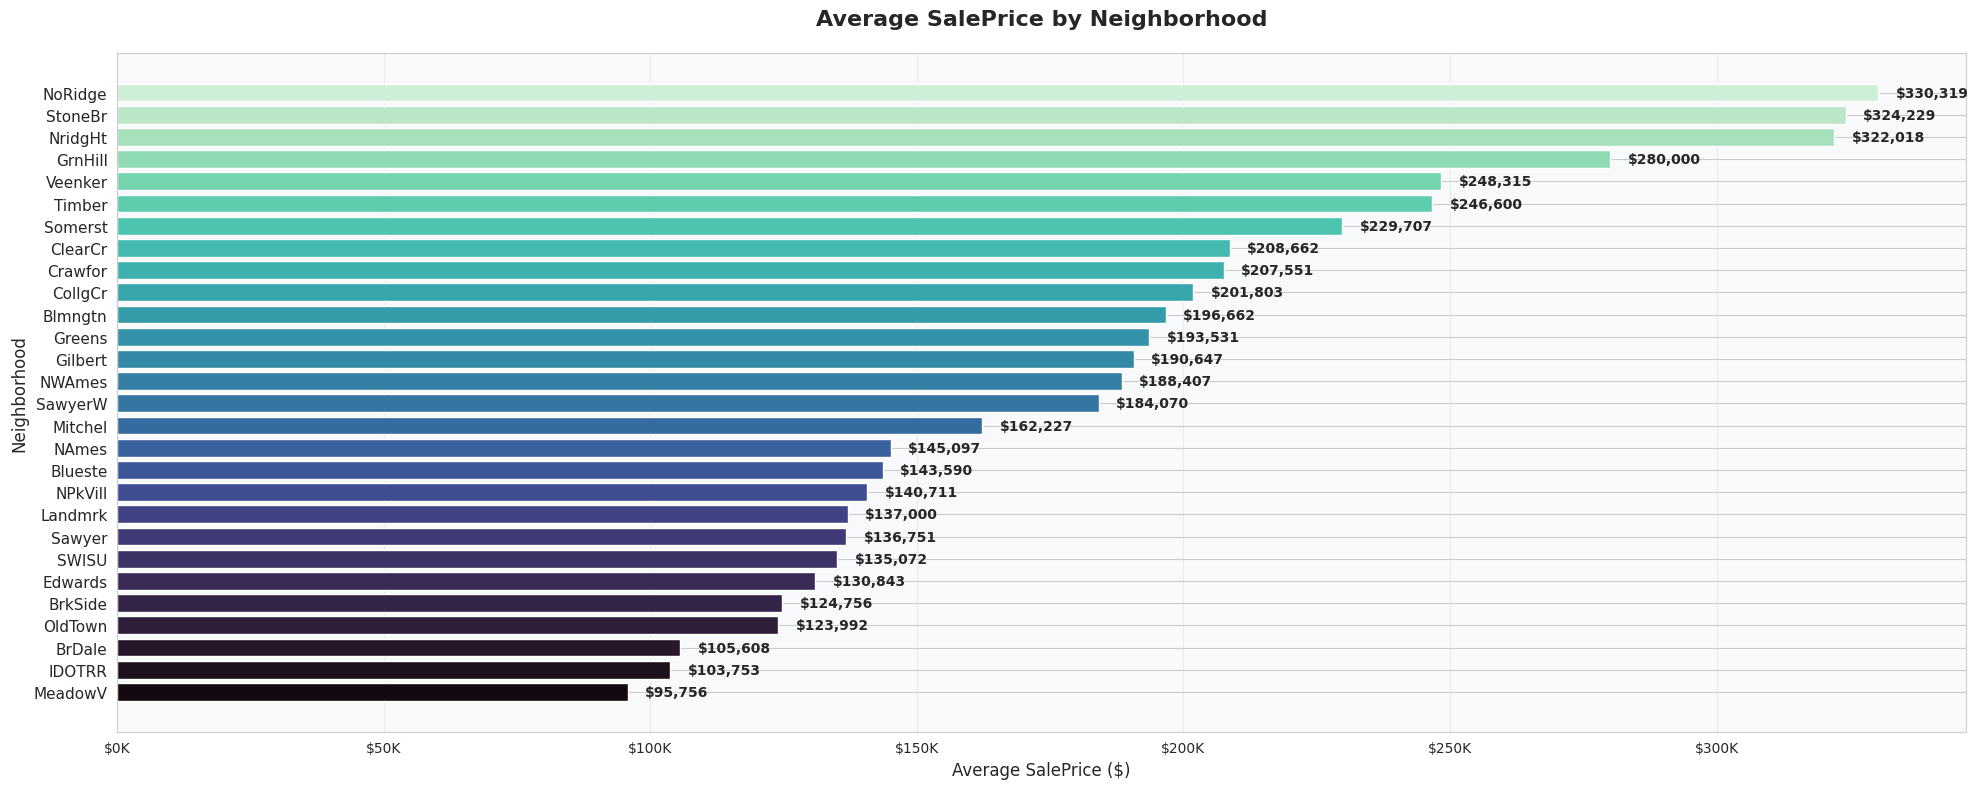

In [31]:
# Task 3: Analyze Relationships with Categorical Features
# Select key categorical features (excluding Neighborhood for separate plot)
categorical_features = ['Overall Qual', 'Garage Cars', 'Exter Qual', 'Kitchen Qual']

# Create enhanced bar plots for the selected features (2x2 layout)
plt.figure(figsize=(16, 12))
for i, feature in enumerate(categorical_features):
    plt.subplot(2, 2, i + 1)

    # Calculate mean SalePrice and sort
    mean_prices = df_train.groupby(feature)['SalePrice'].mean().sort_values()

    # Create bar plot with mako palette
    bars = plt.bar(range(len(mean_prices)), mean_prices.values,
                   color=sns.color_palette('mako', len(mean_prices)))

    # Add value labels on top of bars
    for j, v in enumerate(mean_prices.values):
        plt.text(j, v + max(mean_prices.values)*0.01, f'${v:,.0f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Customize plot
    plt.title(f'SalePrice vs {feature}', fontweight='bold', fontsize=14, pad=20)
    plt.xticks(range(len(mean_prices)), mean_prices.index, rotation=0, fontsize=11)
    plt.ylabel('Average SalePrice ($)', fontsize=11)
    plt.xlabel(feature, fontsize=11)
    plt.grid(True, alpha=0.3, axis='y')
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

# Separate larger plot for Neighborhood
plt.figure(figsize=(20, 8))
mean_prices_neighborhood = df_train.groupby('Neighborhood')['SalePrice'].mean().sort_values()

# Create horizontal bar plot with mako palette
bars = plt.barh(range(len(mean_prices_neighborhood)), mean_prices_neighborhood.values,
                color=sns.color_palette('mako', len(mean_prices_neighborhood)))

# Add value labels
for j, v in enumerate(mean_prices_neighborhood.values):
    plt.text(v + max(mean_prices_neighborhood.values)*0.01, j, f'${v:,.0f}',
            va='center', ha='left', fontsize=10, fontweight='bold')

# Customize plot
plt.title('Average SalePrice by Neighborhood', fontweight='bold', fontsize=16, pad=20)
plt.yticks(range(len(mean_prices_neighborhood)), mean_prices_neighborhood.index, fontsize=11)
plt.xlabel('Average SalePrice ($)', fontsize=12)
plt.ylabel('Neighborhood', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Add background color gradient
plt.gca().set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

### **3. Analysis of Categorical Feature Relationships**
The bar plots clearly show how different categories within a feature affect the average SalePrice.

**Key Observations:**

*  OverallQual: The bar chart reinforces the scatter plot's findings. There is a clear, monotonic increase in average SalePrice as the OverallQual rating goes from 1 to 10.

*  ExterQual (Exterior quality): The plot shows a significant jump in average price as the quality rating increases from Fa (Fair) to Ex (Excellent). This confirms its importance as a predictor.

*  KitchenQual (Kitchen quality): Similar to ExterQual, there is a clear, upward trend in average SalePrice as the kitchen quality improves.

**Conclusion**:

*These categorical features are highly predictive of SalePrice. They are not just labels; they represent a significant portion of a home's value. We'll need to use techniques like one-hot encoding or label encoding to convert these into a numerical format that our machine learning models can understand.*

### **Phase 4: Feature Engineering and Data Preprocessing**

* *Task 1: Handle the Target Variable Transformation*
* *Task 2: Handle Outliers*
* *Task 3: Feature Engineering (Creating New Features)*
* *Task 4: Encoding Categorical Features*


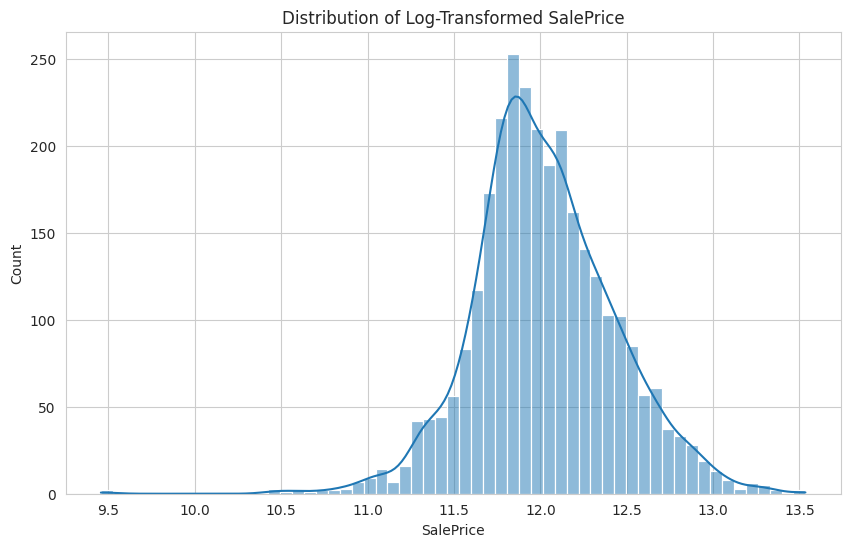

In [32]:
# Task 1: Handle the Target Variable Transformation

# Save the original SalePrice for later use, if needed
y_train = df_train['SalePrice']

# Apply log transformation (using log1p which is often preferred)
y_log = np.log1p(df_train['SalePrice'])

# Optional: Plot the transformed distribution to confirm it's more normal
plt.figure(figsize=(10, 6))
sns.histplot(y_log, kde=True)
plt.title('Distribution of Log-Transformed SalePrice')
plt.show()

# Update your DataFrame to use the log-transformed target variable
df_train['SalePrice'] = y_log

In [33]:
# Task 2: Handle Outliers
# Drop rows where 'Gr Liv Area' is greater than 4000 and SalePrice is low (visual inspection)
df_train = df_train.drop(df_train[(df_train['Gr Liv Area'] > 4000) & (df_train['SalePrice'] < 12.5)].index)

df_train = df_train.drop(df_train[df_train['Garage Area'] > 1400].index)


In [34]:
# Task 3: Feature Engineering (Creating New Features)

# 1. Total Square Footage
df_train['TotalSF'] = df_train['Total Bsmt SF'] + df_train['1st Flr SF'] + df_train['2nd Flr SF']

# 2. Years Since Remodel
df_train['YearsSinceRemodel'] = df_train['Yr Sold'] - df_train['Year Remod/Add']

# 3. Total Bathrooms
df_train['TotalBath'] = df_train['Full Bath'] + (0.5 * df_train['Half Bath']) + \
                        df_train['Bsmt Full Bath'] + (0.5 * df_train['Bsmt Half Bath'])

# 4. Creating a simple 'Has_Pool' feature from 'PoolArea' (Example of binary feature)
df_train['HasPool'] = df_train['Pool Area'].apply(lambda x: 1 if x > 0 else 0)

In [35]:
# Task 4: Encoding Categorical Features

# Identify all categorical features
categorical_cols = df_train.select_dtypes(include='object').columns

# Perform One-Hot Encoding
df_train = pd.get_dummies(df_train, columns=categorical_cols, dummy_na=False)

### **Phase 5: Model Building and Evaluation**


* *Task 1: Prepare Data for Modeling (Splitting and Scaling)*
* *Task 2: Model Training (Baseline and Advanced)*
* *Task 3: Model Evaluation and Comparison*



In [36]:
# Task 1: Prepare Data for Modeling (Splitting and Scaling)

# Drop the log-transformed target variable from X
X = df_train.drop(['SalePrice', 'Order'], axis=1)
y = df_train['SalePrice'] # This is the log-transformed y_log

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify numerical columns for scaling
# Select columns that are not binary (i.e., those not created by get_dummies)
# A simple way: find columns with more than 2 unique values and not object type (should be none now)
# We need to manually identify the numerical columns that weren't one-hot encoded
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# Instantiate the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Data split and scaled successfully.")

Data split and scaled successfully.


**Task 2: Model Training (Baseline and Advanced)**

We'll start with a basic model and move to a more complex one.

Baseline Model (Ridge Regression): Ridge regression is a simple, yet powerful, linear model that adds L2 regularization, which is excellent for dealing with the high number of features (many of which are from your one-hot encoding).

Advanced Model (XGBoost Regressor): Gradient Boosting Machines (like XGBoost) are typically the top performers in structured data competitions like Kaggle. This will test your knowledge of more advanced models.

In [37]:
from sklearn.linear_model import Ridge
import xgboost as xgb

# 1. Ridge Regression
ridge_model = Ridge(alpha=1.0) # alpha is the regularization strength
ridge_model.fit(X_train, y_train)

# 2. XGBoost Regressor
# These are default, good starting hyperparameters
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

print("Models trained successfully.")

Models trained successfully.


In [38]:
# Task 3: Model Evaluation and Comparison

from sklearn.metrics import mean_squared_error

# 1. Make Predictions
ridge_pred_log = ridge_model.predict(X_test)
xgb_pred_log = xgb_model.predict(X_test)

# 2. Inverse Transform Predictions (Crucial Step!)
# Remember: y_test is also log-transformed, so we need to inverse transform both
y_test_original = np.expm1(y_test)
ridge_pred_original = np.expm1(ridge_pred_log)
xgb_pred_original = np.expm1(xgb_pred_log)

# 3. Calculate RMSE (using the original scale for a meaningful result)
ridge_rmse = np.sqrt(mean_squared_error(y_test_original, ridge_pred_original))
xgb_rmse = np.sqrt(mean_squared_error(y_test_original, xgb_pred_original))

print("\n--- Model Evaluation (RMSE in USD) ---")
print(f"Ridge Regression Test RMSE: ${ridge_rmse:,.2f}")
print(f"XGBoost Regressor Test RMSE: ${xgb_rmse:,.2f}")


--- Model Evaluation (RMSE in USD) ---
Ridge Regression Test RMSE: $18,383.28
XGBoost Regressor Test RMSE: $20,305.44


### **Phase 6: Model Refinement (Updated Plan)**

* *Task 1: Hyperparameter Tuning (Ridge Model)*
* *Task 2: Hyperparameter Tuning (XGBoost Model)*
* *Task 3: Final Evaluation and Comparison*



In [39]:
# Task 1: Hyperparameter Tuning (Ridge Model)

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid for alpha
ridge_param_grid = {'alpha': [0.1, 1.0, 10.0, 50.0, 100.0]}

# 2. Instantiate GridSearchCV
ridge_grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=0
)

# Fit the grid search to the training data
ridge_grid.fit(X_train, y_train)

# Get the best Ridge model
best_ridge_model = ridge_grid.best_estimator_

print("Best Alpha for Ridge Regression:", ridge_grid.best_params_['alpha'])

Best Alpha for Ridge Regression: 10.0


In [40]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# Instantiate the XGBoost model
xgb_tuned = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Define the parameter grid to search
# We're testing a few key parameters that control complexity and learning
param_grid = {
    'n_estimators': [150, 300, 500],       # Number of boosting rounds (trees)
    'max_depth': [3, 5, 7],                # Maximum depth of a tree
    'learning_rate': [0.03, 0.07, 0.1]     # Step size shrinkage used to prevent overfitting
}

# Instantiate GridSearchCV with 5-fold cross-validation
# We'll use the negative mean squared error as the scoring metric, as GridSearchCV minimizes the score
grid_search = GridSearchCV(
    estimator=xgb_tuned,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=2, # Verbose 2 will give you more output during the process
    n_jobs=-1  # Use all available cores for faster computation
)

# Fit the grid search to the training data
# NOTE: This step will take some time as it trains 3 * 3 * 3 = 27 models, 5 times each!
grid_search.fit(X_train, y_train)


# Get the best estimator and parameters
best_xgb_model = grid_search.best_estimator_
best_xgb_params = grid_search.best_params_

print("\nBest Parameters found by Grid Search for XGBoost:")
print(best_xgb_params)


Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best Parameters found by Grid Search for XGBoost:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500}


In [41]:
# Task 3: Final Evaluation and Compariso

# --- Step 1: Instantiate Tuned Models ---
# 1. Tuned Ridge Model
tnued_ridge_model = Ridge(alpha=10.0)

# 2. Tuned XGBoost Model
tuned_xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

# --- Step 2: Train Final Models on Training Data ---
tnued_ridge_model.fit(X_train, y_train)
tuned_xgb_model.fit(X_train, y_train)

# --- Step 3: Predict and Evaluate ---
# Make predictions (still in log-scale)
ridge_pred_log = tnued_ridge_model.predict(X_test)
xgb_pred_log = tuned_xgb_model.predict(X_test)

# Inverse Transform predictions and y_test (Crucial!)
y_test_original = np.expm1(y_test)
ridge_pred_original = np.expm1(ridge_pred_log)
xgb_pred_original = np.expm1(xgb_pred_log)

# Calculate Final RMSE (in original USD scale)
tuned_ridge_rmse = np.sqrt(mean_squared_error(y_test_original, ridge_pred_original))
tuned_xgb_rmse = np.sqrt(mean_squared_error(y_test_original, xgb_pred_original))

# --- Print Final Results ---
print("\n--- Final Model Performance Comparison (RMSE in USD) ---")
print(f"1. Baseline Ridge RMSE (Original):    $18,383.28")
print(f"2. Tuned Ridge Model RMSE:            ${tuned_ridge_rmse:,.2f}")
print(f"3. Tuned XGBoost Model RMSE:          ${tuned_xgb_rmse:,.2f}")

# Determine the winner
if tuned_ridge_rmse < tuned_xgb_rmse:
    print("\n--- Winner: Tuned Ridge Model ---")
elif tuned_ridge_rmse > tuned_xgb_rmse:
    print("\n--- Winner: Tuned XGBoost Model ---")


--- Final Model Performance Comparison (RMSE in USD) ---
1. Baseline Ridge RMSE (Original):    $18,383.28
2. Tuned Ridge Model RMSE:            $18,013.29
3. Tuned XGBoost Model RMSE:          $19,311.93

--- Winner: Tuned Ridge Model ---


In [42]:
# Svaing the model
import joblib
joblib.dump(best_ridge_model, 'house_price_model.pkl')


['house_price_model.pkl']


### Takeaways

1.  **Data Transformation is More Powerful Than Model Complexity:**
    * **Insight:** The Tuned Ridge Regression (a linear model) achieved an RMSE of **\$18,013.29**, outperforming the highly complex, non-linear Tuned XGBoost model.
    * **Lesson Learned:** The success was not due to the model's complexity, but the effective transformation of the data. The **log-transformation of the target variable ({SalePrice})** was the single most crucial step, as it linearized the relationship, allowing a fast, interpretable linear model to achieve peak performance.

2.  **The Value of Feature Engineering:**
    * **Insight:** Creating composite features (like **TotalSF** and **TotalBath**) was a key factor in simplifying the problem for the linear model. These features capture the holistic value of the home much better than individual components, directly improving model accuracy.
    * **Lesson Learned:** Before resorting to complex models, invest heavily in domain-driven feature engineering. Good features reduce the *need* for algorithmic complexity.

3.  **Regularization is Essential with High-Dimensional Data:**
    * **Insight:** the project involved one-hot encoding a large number of categorical variables, creating a very wide dataset. Ridge Regression's L2 regularization was highly effective in managing this high dimensionality and multicollinearity.
    * **Lesson Learned:** When dealing with datasets expanded by one-hot encoding, regularization (Lasso or Ridge) is mandatory to prevent overfitting and to stabilize model coefficients.

4.  **The Importance of a Robust Benchmarking Process:**
    * **Insight:** The initial benchmark showed Ridge (18,383.28$) beating default XGBoost (20,305.44$). This immediately signaled that the problem might be more linear than expected, guiding the tuning strategy.
    * **Lesson Learned:** Always establish a strong, simple baseline. If a simple model is competitive, it indicates a high-quality data preparation phase and suggests that tuning the simpler model may yield the best trade-off between performance and interpretability.

5.  **Critical Evaluation (The Inverse Transform):**
    * **Insight:** The need to use `np.expm1()` to inverse transform the final log-predictions back to USD was the only way to calculate a meaningful RMSE (\$18,013.29, not a log-scale value).
    * **Lesson Learned:** When transformations are used, the evaluation metric must always be computed on the original scale to provide an interpretable result that stakeholders (like real estate agents) can understand.

